# Day 3 — MLP (makemore Part 2, video 3, 1h15m)

The bigram's fatal flaw: one character of context. This video: 3 characters of context → embedding table C → hidden layer → 27-way output. (Bengio et al. 2003, the paper that started neural language modeling.)

Big NEW concepts to watch for (none of these existed in my week so far):
- **Embeddings** — characters become learned vectors, not one-hots
- **Minibatches** — training on random subsets, not the full data every step
- **Learning-rate finding** — the principled way, not vibes
- **Train/dev/test splits and overfitting** — why one loss number stops being enough

MY exercises: dataset with context window, C lookup, hidden layer forward, loss (meet `F.cross_entropy`), minibatch training loop, splits, sampler. Boilerplate: loader + maps below (built them from memory twice — they're plumbing now).

In [551]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [552]:
# HYPERPARAMETERS
BLOCK_SIZE = 4              # context length (chars of history)
EMBEDDINGS_DIMENSION = 12    # size of each character's learned vector
HIDDEN_WIDTH = 100          # neurons in the hidden layer
LEARNING_RATE = 0.085        # from my lr sweep (valley ~10^-1)
BATCH_SIZE = 64            # minibatch rows per step
STEPS = 90000               # training iterations

VOCAB_SIZE = 27             # forced by the data (26 letters + '.'), not a knob

In [553]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [554]:
len(words)

32033

In [555]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [556]:
def build_dataset(word_list, block_size):
    X, Y = [], []

    for word in word_list:
        context = [0] * block_size
        for ch in word + ".":
            ix = stoi[ch]
            Y.append(ix)
            X.append(context)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

In [557]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1],   BLOCK_SIZE)
Xdev, Ydev = build_dataset(words[n1:n2], BLOCK_SIZE)
Xte,  Yte  = build_dataset(words[n2:],   BLOCK_SIZE)

print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 4]) torch.Size([22655, 4]) torch.Size([22866, 4])


In [558]:
Xtr.shape

torch.Size([182625, 4])

In [559]:
Ytr.shape

torch.Size([182625])

In [560]:
# we need to build look up table C, which is the embedding lookup table
g = torch.Generator().manual_seed(2147483647)
W1 = torch.randn(((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH)), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g)

# Layer two params
# For layer 2, there are 27 outputs.
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn((VOCAB_SIZE), generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

emb = C[Xtr]

In [561]:
emb.shape

torch.Size([182625, 4, 12])

In [562]:
O1 = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE) @ W1 + B1 # -1 is like telling pytorch to autofill the correct value
O1 = O1.tanh()
O1.shape

torch.Size([182625, 100])

In [563]:
logits = O1 @ W2 + B2

In [564]:
# count = logits.exp()
# prob = count/count.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
# loss

In [565]:
# Better way to calculate loss
loss = F.cross_entropy(logits, Ytr)
loss

tensor(20.7401, grad_fn=<NllLossBackward0>)

In [566]:
loss.backward()

In [567]:
for p in parameters:
    p.data += -LEARNING_RATE * p.grad

Now, all put together to tune the model

In [568]:
g = torch.Generator().manual_seed(2147483647)

# There are three inputs put into the initial neural network with two dimensions: 3 × 2 = 6.
W1 = torch.randn((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g) # 27 since there are 26 alphabets + 1 . special char

# Second layer
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn(VOCAB_SIZE, generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

for i in range(100):

    # Embedding lookup table where you can see the corresponding embedggings for any index in X from C
    emb = C[Xtr] # size -> [xyz, BLOCK_SIZE, EMBEDDINGS_DIMENSION]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)

    # Output of the first layer, which is the input to the second
    O1 = emb_view @ W1 + B1
    O1 = O1.tanh()
    logit = O1 @ W2 + B2
    loss = F.cross_entropy(logit, Ytr)

    for p in parameters:
        p.grad = None

    loss.backward()

    for p in parameters:
        p.data += -LEARNING_RATE * p.grad

loss.item()

8.538530349731445

In [569]:
ix = 0
word = []
context = [0] * BLOCK_SIZE

for i in range(5):
    while True:
        emb = C[torch.tensor(context)]
        O1 = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE) @ W1 + B1
        O1 = O1.tanh()

        context = context[1:] + [ix]

        logit = O1 @ W2 + B2
        # count = logit.exp()
        # prob = count/count.sum(1, keepdim=True)
        prob = F.softmax(logit, dim=1)

        ix = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()

        ch = itos[ix]

        word.append(ch)

        if ix == 0: 
            print(('').join(word))
            break


vsnymrzesulus.
vsnymrzesulus..
vsnymrzesulus..mdiefonneyaec.
vsnymrzesulus..mdiefonneyaec.vriam.
vsnymrzesulus..mdiefonneyaec.vriam.jdtoffddpgfmmlkwlam.


In [570]:
# QUESTION: How do we find the best learning rate?
lre = torch.linspace(-3, 0, 1000) # Learning rate exponential: it's basically a range from -3 to 0, but when it gets exponentiated, it's from -0.001 to 1,000 steps.
lrs = 10**lre

In [571]:
Xtr.shape

torch.Size([182625, 4])

In [572]:
g = torch.Generator().manual_seed(2147483647)
lri = []
lossi = []

# forward pass
# There are three inputs put into the initial neural network with two dimensions: 3 × 2 = 6.
W1 = torch.randn((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g) # 27 since there are 26 alphabets + 1 . special char

# Second layer
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn(VOCAB_SIZE, generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

for i in range(1000):

    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    # Embedding lookup table where you can see the corresponding embedggings for any index in X from C
    emb = C[Xtr[ix]] # size -> [xyz, BLOCK_SIZE, EMBEDDINGS_DIMENSION]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)

    # Output of the first layer, which is the input to the second
    O1 = emb_view @ W1 + B1
    O1 = O1.tanh()
    logit = O1 @ W2 + B2
    loss = F.cross_entropy(logit, Ytr[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    lri.append(lre[i])
    lossi.append(loss.item())


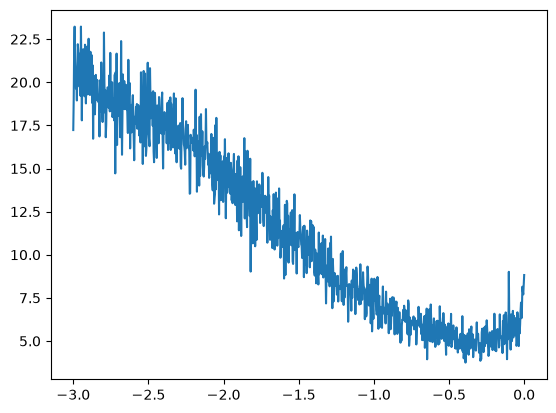

In [573]:
plt.plot(lri, lossi)
# From the graph, we can see that the best learning rate is around -1-ish. So we set that as a learning rate.
# lr = 10*-1

In [574]:
g = torch.Generator().manual_seed(2147483647)
lossi = []
stepi = []

# forward pass
# There are three inputs put into the initial neural network with two dimensions: 3 × 2 = 6.
W1 = torch.randn((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g) # 27 since there are 26 alphabets + 1 . special char

# Second layer
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn(VOCAB_SIZE, generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

for i in range(STEPS):

    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    # Embedding lookup table where you can see the corresponding embedggings for any index in X from C
    emb = C[Xtr[ix]] # size -> [xyz, BLOCK_SIZE, EMBEDDINGS_DIMENSION]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)

    # Output of the first layer, which is the input to the second
    O1 = emb_view @ W1 + B1
    O1 = O1.tanh()
    logit = O1 @ W2 + B2
    loss = F.cross_entropy(logit, Ytr[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = LEARNING_RATE
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    stepi.append(i)
    lossi.append(loss.item())

print(loss.item())

2.2471745014190674


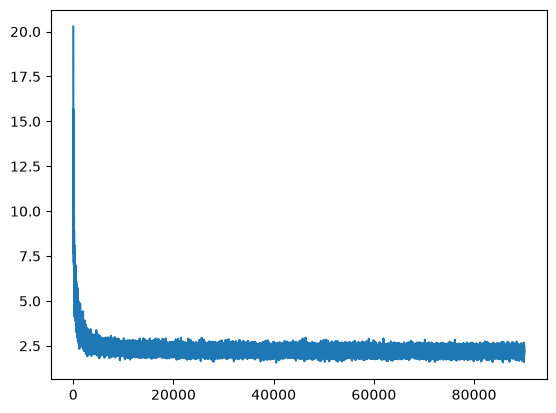

In [575]:
plt.plot(stepi, lossi)

## EXERCISE — the leaderboard (dev loss is the only score that counts)

| model | dev loss |
|---|---|
| uniform ignorance | 3.29 |
| bigram (counting, part 1) | 2.45 — **BEATEN** |
| my honest baseline (emb 2, hidden 100, 10k steps) | 2.499 |
| lecture, same-size model | ~2.3 — **BEATEN** |
| **mine, current best** (block 4, emb 12, hidden 100, batch 64, lr 0.085, 90k steps) | **2.188** (train 2.162 — small gap opening, healthy) |
| lecture final — Karpathy's challenge | **2.17 — 0.018 away** |

**CURRENT GOAL: dev < 2.17.** Ideas with room left: HIDDEN_WIDTH is still 100 (lecture used 200); lr decay for the last ~20k steps (drop LEARNING_RATE ~10x); more steps. Watch the train/dev gap — if it widens past ~0.05, capacity is outrunning the data.
Rules: knobs in the dashboard only · judge on dev only · test stays sealed until the final model.

In [576]:
@torch.no_grad()
def split_loss(X, Y):
    emb = C[X]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)
    O1 = (emb_view @ W1 + B1).tanh()
    logit = O1 @ W2 + B2
    return F.cross_entropy(logit, Y).item()

# train set
print("train loss:", split_loss(Xtr, Ytr))
# dev set
print("dev loss:  ", split_loss(Xdev, Ydev))

train loss: 2.1617233753204346
dev loss:   2.1875457763671875


In [577]:
# test set
# print("test loss:  ", split_loss(Xtest, Ytest))